<a href="https://colab.research.google.com/github/whup-whup/NMA_Project/blob/main/NMA_HCP_3T_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Install dependencies
!pip install nilearn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#@title Figure settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
##plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [ ]:
# The data shared for NMA projects is a subset of the full HCP dataset
N_SUBJECTS = 100

# The data have already been aggregated into ROIs from the Glasser parcellation
N_PARCELS = 360

# The acquisition parameters for all tasks were identical
TR = 0.72  # Time resolution, in seconds

# The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated twice in each subject
RUNS   = ['LR','RL']
N_RUNS = 2

# There are 7 tasks. Each has a number of 'conditions'
# TIP: look inside the data folders for more fine-graned conditions

EXPERIMENTS = {
    'MOTOR'      : {'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools','2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'cond':['fear','neut']},
    'GAMBLING'   : {'cond':['loss','win']},
    'LANGUAGE'   : {'cond':['math','story']},
    'RELATIONAL' : {'cond':['match','relation']},
    'SOCIAL'     : {'cond':['ment','rnd']}
}

In [ ]:
## This block is just to load all the data and the functions that were predefined in the HCP booklet

## Downloading the data
# @title Download data file
import os, requests

fname = "hcp_task.tgz"
url = "https://osf.io/2y3fw/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)


# The download cells will store the data in nested directories starting here:
HCP_DIR = "./hcp_task"

# importing the "tarfile" module
import tarfile

# open file
with tarfile.open(fname) as tfile:
  # extracting file
  tfile.extractall('.')

subjects = np.loadtxt(os.path.join(HCP_DIR, 'subjects_list.txt'), dtype='str')


regions = np.load(f"{HCP_DIR}/regions.npy").T
region_info = dict(
    name=regions[0].tolist(),
    network=regions[1],
    hemi=['Right']*int(N_PARCELS/2) + ['Left']*int(N_PARCELS/2),
)


def load_single_timeseries(subject, experiment, run, remove_mean=True):
  """Load timeseries data for a single subject and single run.

  Args:
    subject (str):      subject ID to load
    experiment (str):   Name of experiment
    run (int):          (0 or 1)
    remove_mean (bool): If True, subtract the parcel-wise mean (typically the mean BOLD signal is not of interest)

  Returns
    ts (n_parcel x n_timepoint array): Array of BOLD data values

  """
  bold_run  = RUNS[run]
  bold_path = f"{HCP_DIR}/subjects/{subject}/{experiment}/tfMRI_{experiment}_{bold_run}"
  bold_file = "data.npy"
  ts = np.load(f"{bold_path}/{bold_file}")
  if remove_mean:
    ts -= ts.mean(axis=1, keepdims=True)
  return ts

def load_evs(subject, experiment, run):
  """Load EVs (explanatory variables) data for one task experiment.

  Args:
    subject (str): subject ID to load
    experiment (str) : Name of experiment
    run (int): 0 or 1

  Returns
    evs (list of lists): A list of frames associated with each condition

  """

  if experiment== 'EMOTION':
    #print('Lessgoo')
    frames_list = []
    task_key = f'tfMRI_{experiment}_{RUNS[run]}'
    for cond in EXPERIMENTS[experiment]['cond']:
      ev_file  = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
      ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
      ev       = dict(zip(["onset", "duration", "amplitude"], ev_array))
      # Determine when trial starts, rounded down
      start = np.floor(ev["onset"] / TR).astype(int)
      # Use trial duration to determine how many frames to include for trial
      duration = np.ceil(ev["duration"] / TR).astype(int)
      # Take the range of frames that correspond to this specific trial
      frames = [s + np.arange(0, d) for s, d in zip(start, duration)]
      frames = [x[x < 176] for x in frames]
      frames_list.append(frames)



  else:
    frames_list = []
    task_key = f'tfMRI_{experiment}_{RUNS[run]}'
    for cond in EXPERIMENTS[experiment]['cond']:
      ev_file  = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
      ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
      ev       = dict(zip(["onset", "duration", "amplitude"], ev_array))
      # Determine when trial starts, rounded down
      start = np.floor(ev["onset"] / TR).astype(int)
      # Use trial duration to determine how many frames to include for trial
      duration = np.ceil(ev["duration"] / TR).astype(int)
      # Take the range of frames that correspond to this specific trial
      frames = [s + np.arange(0, d) for s, d in zip(start, duration)]
      frames_list.append(frames)



  return frames_list


## Edit to account for emotionss
def average_frames(data, evs, experiment, cond):
  idx = EXPERIMENTS[experiment]['cond'].index(cond)
  blocks = [np.mean(data[:, f], axis=1, keepdims=True)
              for f in evs[idx] if len(f) > 0]
  return np.mean(np.concatenate(blocks, axis=-1), axis=1)
  #idx = EXPERIMENTS[experiment]['cond'].index(cond)
  #return np.mean(np.concatenate([np.mean(data[:, evs[idx][i]], axis=1, keepdims=True) for i in range(len(evs[idx]))], axis=-1), axis=1)




/tmp/ipykernel_1429/3435626986.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall('.')


In [ ]:
def load_exp_data_avg_all_subjects(exp_name,condition,run):
  ## NOTE: run is 0 or 1 where 0 -> 'LR' and 1->'RL'
  ## We are loading the averageof the timeseries data here for the given conditions( run, cond='0back' or 'fear')
  ## for all the subjects and neatly arranging them into a 2D numpy array
  rows=[]
  for i,sub in enumerate(subjects):
    ## exp_data are all the time series data associated with that particular experiment('WM', 'Emotion', etc)
    ## it contains all the conditions for that particular experiment
    exp_data = load_single_timeseries(subject=sub,experiment=exp_name,run=run,remove_mean=True)
    ## evs tells us the location of the conditions for the experiment data ( what is the start and duration for each condition) (I think)
    evs = load_evs(subject=sub, experiment=exp_name, run=run)
    rows.append(average_frames(exp_data, evs, exp_name, condition))
    # if i==0:
    #   data = average_frames(exp_data, evs, exp_name, condition)
    # else:
    #   data= np.vstack((data,average_frames(exp_data, evs, exp_name, condition)))

  return np.stack(rows)



In [ ]:
def visualise_with_columns(data,column_names):
  ## Column names is the array you want to use as the column names
  ## if you want regions data, column_names= regions[0]
  return pd.DataFrame(data,columns=column_names)


In [ ]:
run = 0

bk2_conds = ['2bk_body', '2bk_faces', '2bk_places', '2bk_tools']
bk0_conds = ['0bk_body', '0bk_faces', '0bk_places', '0bk_tools']

data_2bk_run_0 = np.mean([load_exp_data_avg_all_subjects('WM', c, run) for c in bk2_conds], axis=0)  # (100, 360)
data_0bk_run_0 = np.mean([load_exp_data_avg_all_subjects('WM', c, run) for c in bk0_conds], axis=0)  # (100, 360)

run= 1
data_2bk_run_1 = np.mean([load_exp_data_avg_all_subjects('WM', c, run) for c in bk2_conds], axis=0)  # (100, 360)
data_0bk_run_1 = np.mean([load_exp_data_avg_all_subjects('WM', c, run) for c in bk0_conds], axis=0)  # (100, 360)

data_2bk= np.mean([data_2bk_run_0,data_2bk_run_1],axis=0)
data_0bk= np.mean([data_0bk_run_0,data_0bk_run_1],axis=0)

print(data_2bk.shape)
contrast = data_2bk - data_0bk          # (100, 360): per-subject 2bk−0bk
group_contrast = contrast.mean(axis=0)  # (360,): averaged across subjects

## what we essentially did here was for all conditions of 2back (and  0back separately), we
## took the average of each region for the same subject
## then, we computed the contrast (2back- 0back)
## and we took the means of contrast for each region in group contrast

(100, 360)


In [ ]:

visualise_with_columns(data_2bk,regions[0])

,R_V1,R_MST,R_V6,R_V2,R_V3,R_V4,R_V8,R_4,R_3b,R_FEF,...,L_p47r,L_TGv,L_MBelt,L_LBelt,L_A4,L_STSva,L_TE1m,L_PI,L_a32pr,L_p24
0,8.563180,3.565545,-1.453938,7.220346,10.599457,22.557518,17.639439,-2.445879,-6.396108,9.223483,...,1.523324,1.702232,-8.709650,4.911431,-0.767929,2.729028,7.385588,-1.095467,14.292176,14.716654
1,18.860875,0.482723,-17.630020,10.139208,5.551300,17.994575,21.600519,-8.196649,-0.247770,1.801003,...,-18.202879,2.143061,0.457660,1.699847,-0.079765,-5.712276,-2.704176,-0.799080,34.855605,11.251576
2,16.634176,-1.044179,-7.690363,7.322243,9.791123,11.615603,20.398937,-7.615225,-11.431019,6.232087,...,36.107614,19.017392,-12.821335,-3.874127,-3.883036,0.047634,7.324878,-0.244355,32.178963,0.254569
3,32.486674,4.196096,11.472242,23.516721,24.485271,43.918336,39.358468,-12.622748,-8.520609,9.952143,...,20.808721,32.696485,20.084101,11.577667,-0.513612,7.934889,18.696763,10.397649,51.980196,30.454556
4,18.151235,2.771296,-1.479556,12.136452,22.536234,17.144808,21.734938,-10.456771,-16.301839,13.590299,...,7.862456,1.317978,-12.557278,-7.455573,-3.173122,3.621552,2.080019,4.546011,20.462611,0.557002
5,24.052637,13.828766,3.734590,12.197056,15.496992,23.339847,24.484480,4.266421,1.429563,9.800829,...,32.419257,2.659176,-14.811585,-3.705817,7.977645,-3.439565,10.565169,-2.388277,-4.045588,-1.326685
6,9.623572,-0.085961,-13.767983,7.463813,9.284647,11.575230,23.568605,-5.284033,-10.075301,7.164709,...,18.332017,1.666368,-18.958469,-11.673838,-11.697533,-2.447497,-2.041726,-9.670617,4.172434,-11.518034
7,10.207140,-0.620111,6.461799,10.137249,2.938277,9.722399,25.470041,-3.954732,-6.853517,16.253412,...,20.546084,-5.029419,-1.936718,-9.237619,-1.960287,-11.807925,-1.193181,-9.547900,6.241230,16.178075
8,9.896144,4.781415,-15.985271,4.829578,10.178585,14.382067,14.103000,-9.415845,-6.504217,17.607956,...,9.775135,-1.289031,-14.375315,-1.239366,-7.171957,-6.609477,9.857285,-12.883428,47.987030,4.871117
9,11.372878,-0.412861,-5.373585,4.236761,3.324008,10.392703,18.973717,-12.656444,-6.664695,11.593386,...,24.391865,-5.149214,-2.364661,-15.436664,0.033918,-16.775271,0.755611,1.385392,6.998120,-2.212950


In [ ]:
regions[1].shape

(360,)

In [ ]:
network_df= pd.DataFrame({'network':regions[1], 'contrast':group_contrast})
network_df=network_df.groupby(by=['network']).agg({'contrast':'mean'}).reset_index(drop=False).sort_values(by=['contrast'])
network_df

,network,contrast
0,Auditory,-9.537956
8,Somatomotor,-6.481377
11,Visual2,-5.140245
6,Orbito-Affec,-3.446436
10,Visual1,-3.277913
7,Posterior-Mu,-3.146278
9,Ventral-Mult,-2.944856
2,Default,-0.133248
1,Cingulo-Oper,0.812485
3,Dorsal-atten,2.100488


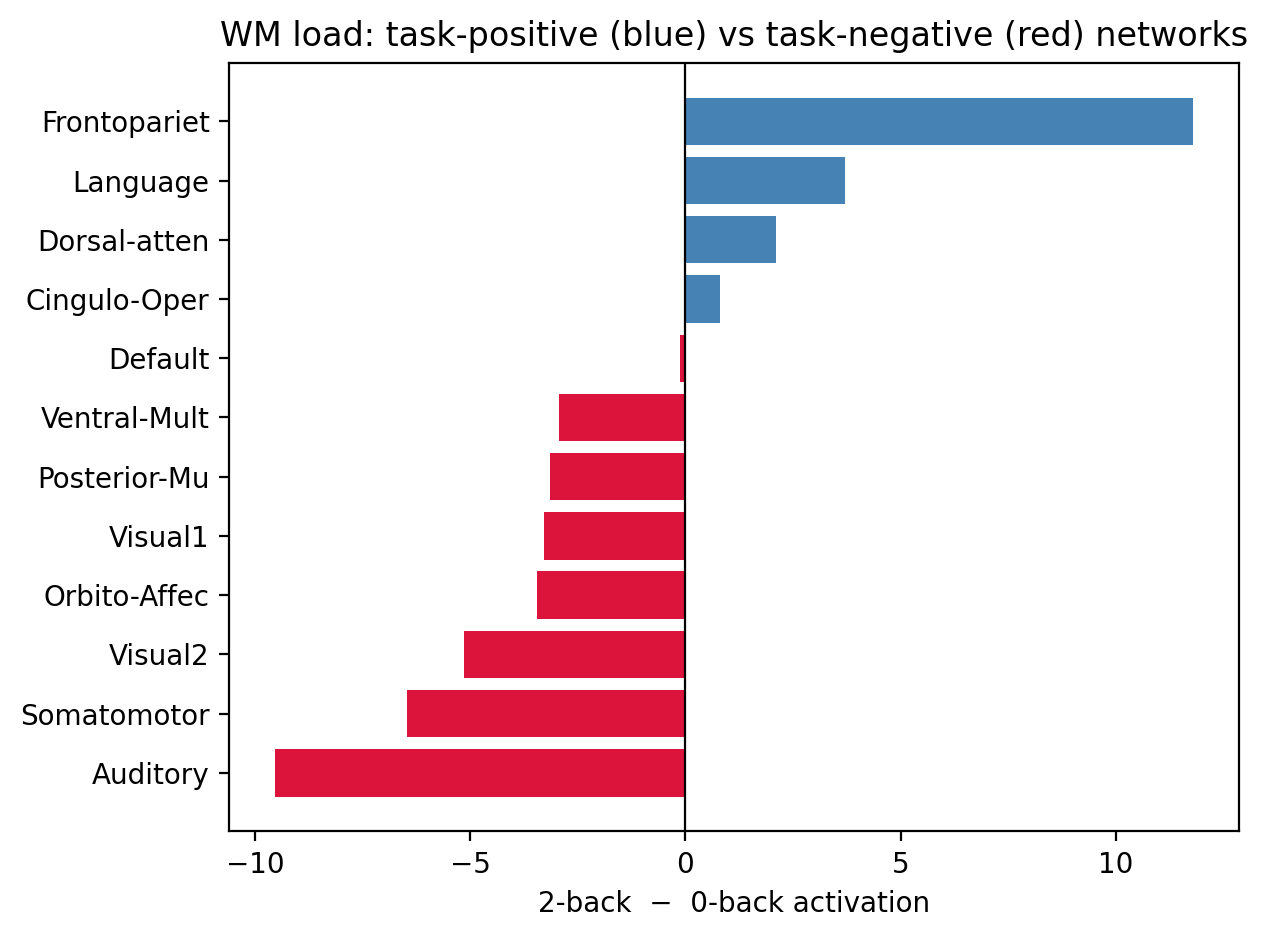

In [ ]:
import matplotlib.pyplot as plt

colors = ['crimson' if v < 0 else 'steelblue' for v in network_df['contrast']]
#network_df.plot(kind='barh', color=colors)
plt.barh(network_df['network'], network_df['contrast'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('2-back  −  0-back activation')
plt.title('WM load: task-positive (blue) vs task-negative (red) networks')
plt.tight_layout()
plt.show()

In [ ]:
## Refrences to this phenomenon
## Main reference: https://pubmed.ncbi.nlm.nih.gov/15976020/
## https://pubmed.ncbi.nlm.nih.gov/12729491/


In [ ]:
## Now Doing the Same for Emotions

run = 0
#'EMOTION'    : {'cond':['fear','neut']},

data_fear = np.mean([load_exp_data_avg_all_subjects('EMOTION', 'fear', r) for r in [0,1]],axis=0)
data_neutral = np.mean([load_exp_data_avg_all_subjects('EMOTION', 'neut', r) for r in [0,1]],axis=0)  # (100, 360)

print(data_fear.shape)

emo_contrast = data_fear - data_neutral          # (100, 360): per-subject 2bk−0bk
emo_group_contrast = emo_contrast.mean(axis=0)  # (360,): averaged across subjects

## what we essentially did here was for all conditions of 2back (and  0back separately), we
## took the average of each region for the same subject
## then, we computed the contrast (2back- 0back)
## and we took the means of contrast for each region in group contrast




(100, 360)


In [ ]:
emo_network_df= pd.DataFrame({'network':regions[1], 'contrast':emo_group_contrast})
emo_network_df=emo_network_df.groupby(by=['network']).agg({'contrast':'mean'}).reset_index(drop=False).sort_values(by=['contrast'])
emo_network_df

,network,contrast
1,Cingulo-Oper,-6.216648
5,Language,-4.739698
8,Somatomotor,-2.657184
4,Frontopariet,-2.065372
7,Posterior-Mu,-0.590626
0,Auditory,0.697345
6,Orbito-Affec,1.483504
2,Default,3.775689
11,Visual2,4.237686
9,Ventral-Mult,4.863010


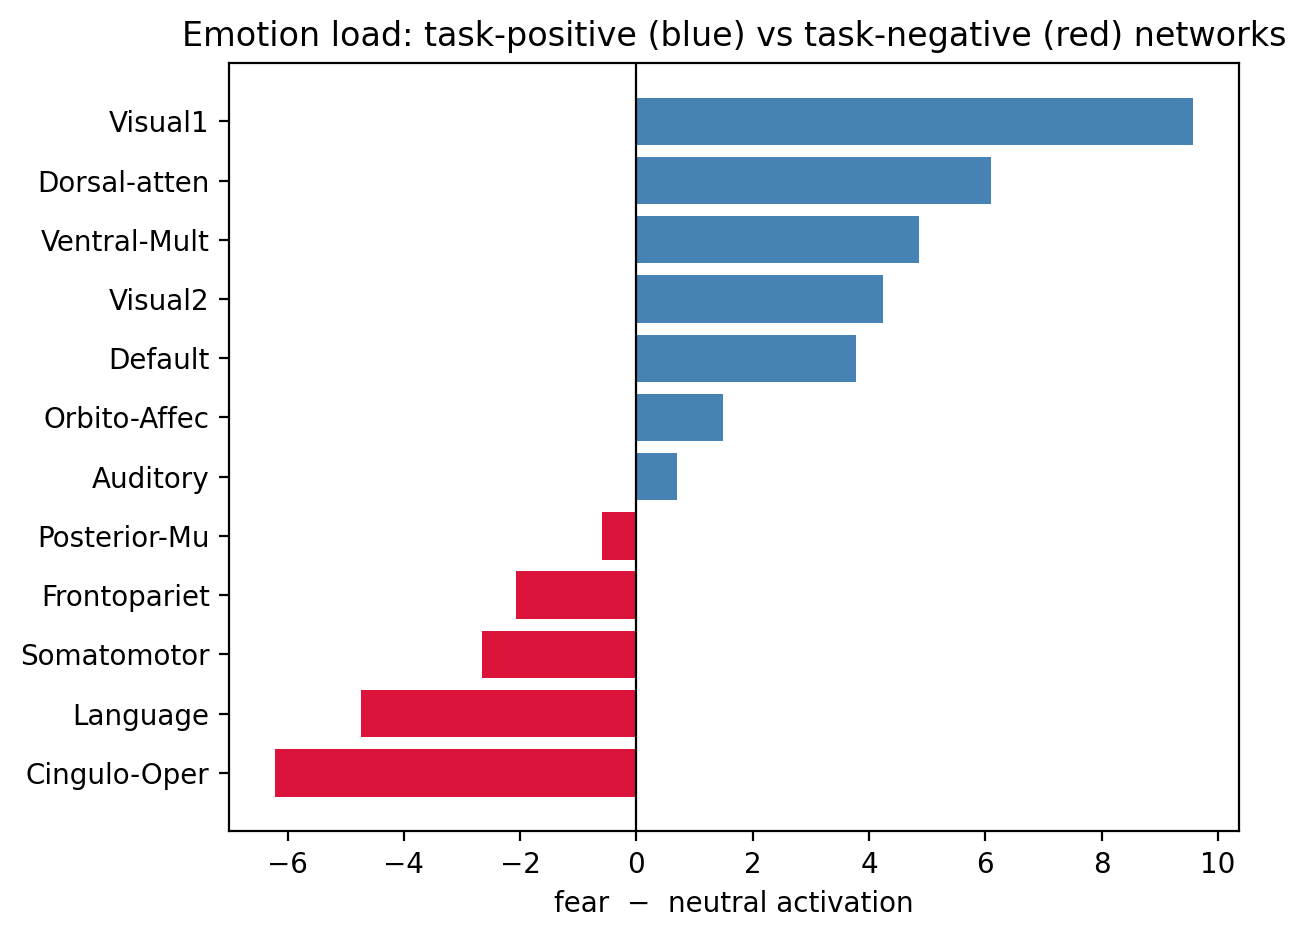

In [ ]:
import matplotlib.pyplot as plt

colors = ['crimson' if v < 0 else 'steelblue' for v in emo_network_df['contrast']]
#network_df.plot(kind='barh', color=colors)
plt.barh(emo_network_df['network'], emo_network_df['contrast'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('fear  −  neutral activation')
plt.title('Emotion load: task-positive (blue) vs task-negative (red) networks')
plt.tight_layout()
plt.show()

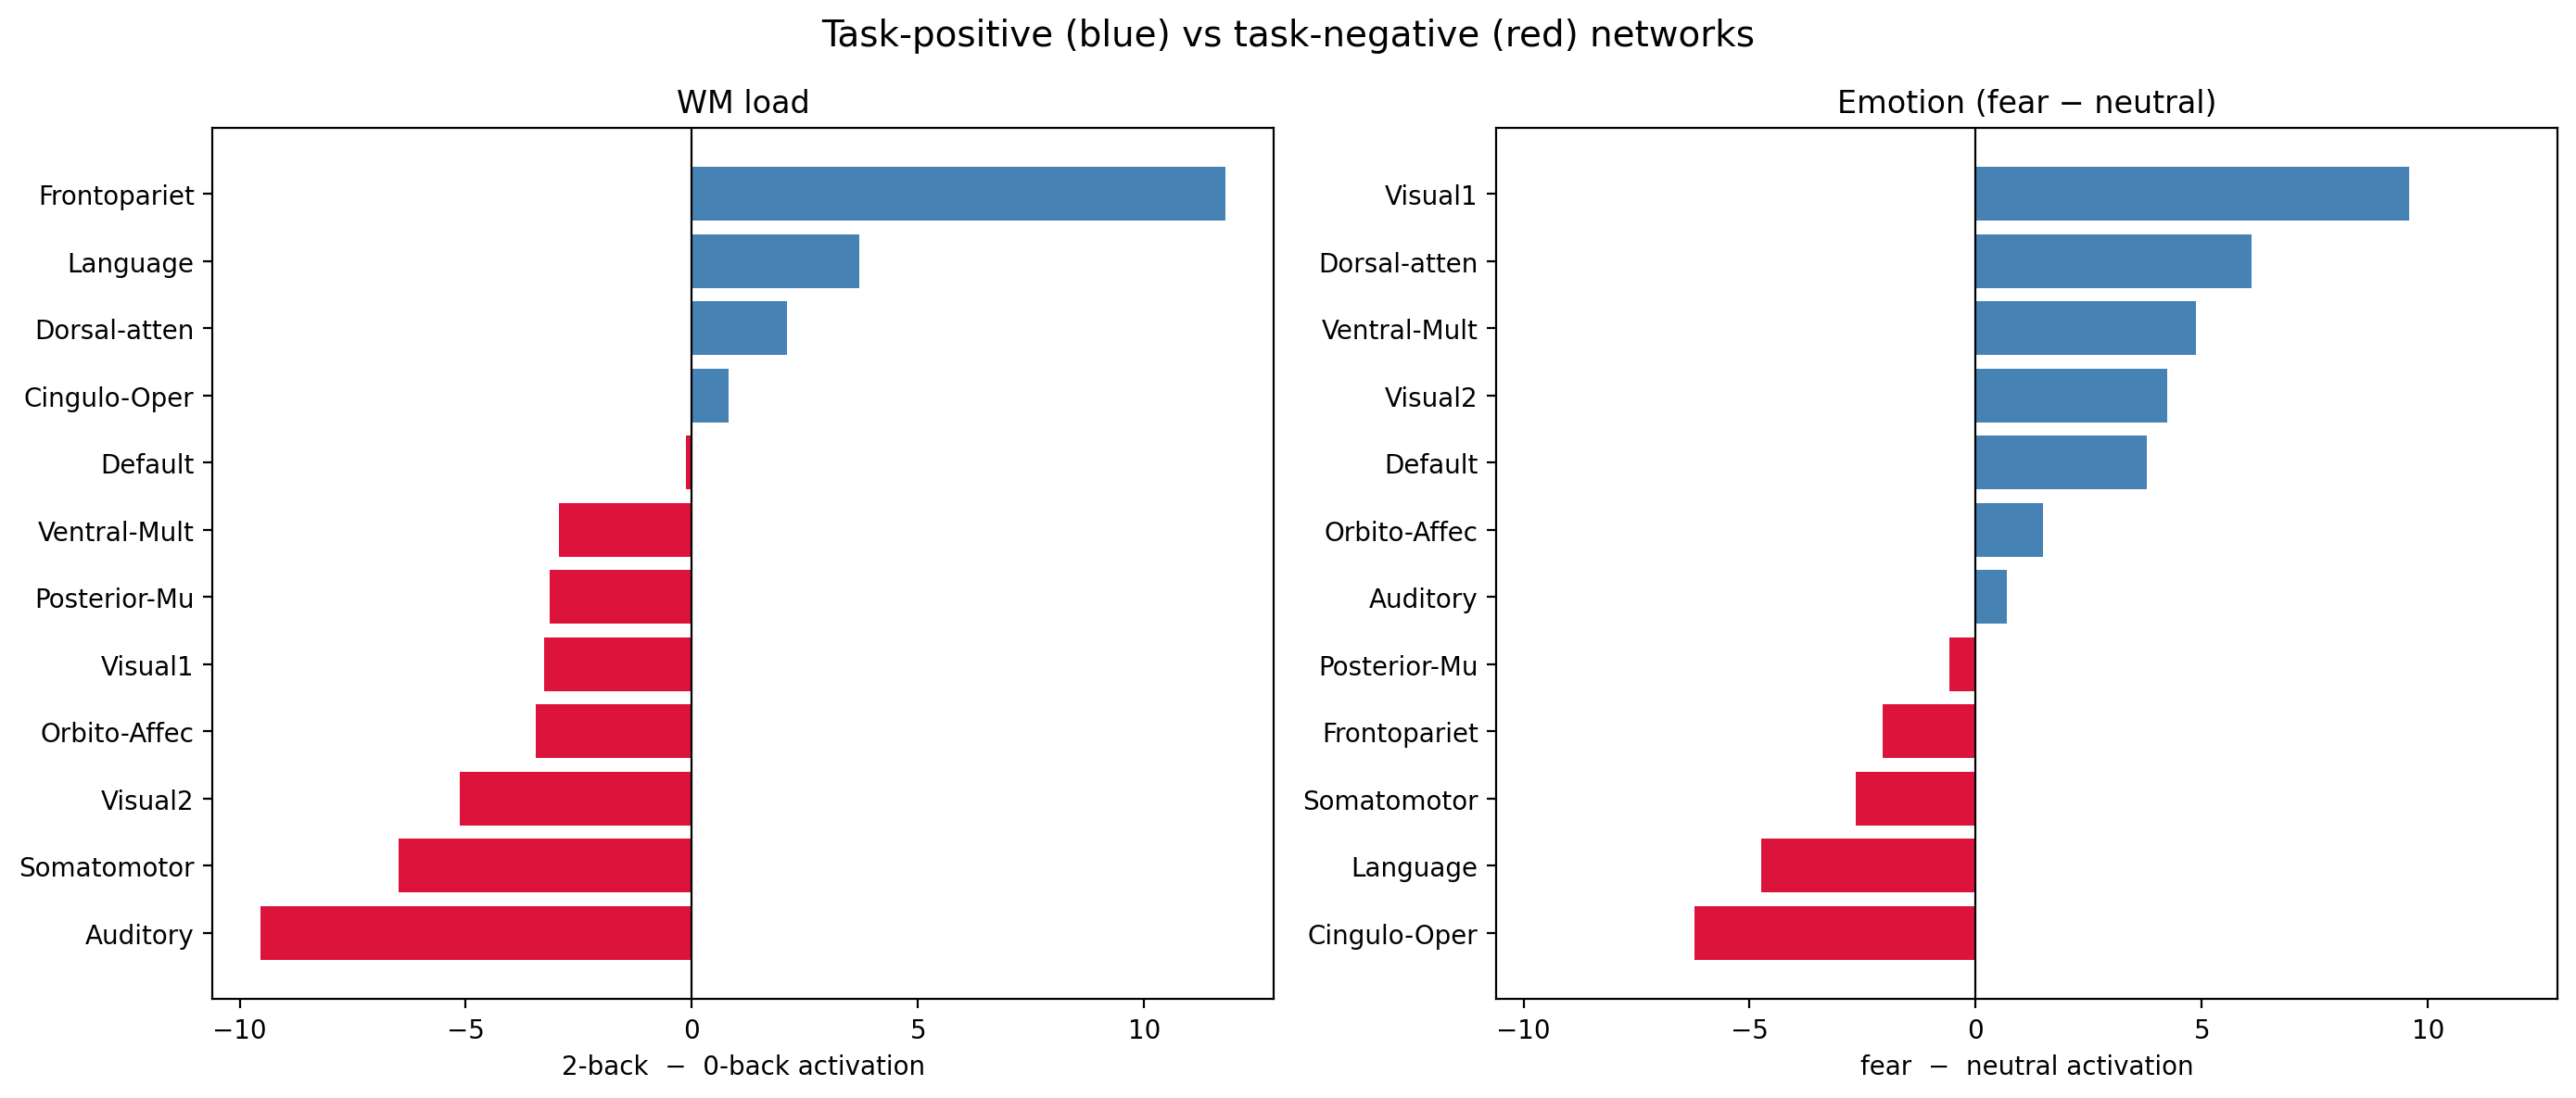

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# --- Left: Working memory ---
colors_wm = ['crimson' if v < 0 else 'steelblue' for v in network_df['contrast']]
ax1.barh(network_df['network'], network_df['contrast'], color=colors_wm)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('2-back  −  0-back activation')
ax1.set_title('WM load')

# --- Right: Emotion ---
colors_emo = ['crimson' if v < 0 else 'steelblue' for v in emo_network_df['contrast']]
ax2.barh(emo_network_df['network'], emo_network_df['contrast'], color=colors_emo)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('fear  −  neutral activation')
ax2.set_title('Emotion (fear − neutral)')

fig.suptitle('Task-positive (blue) vs task-negative (red) networks', fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:

contrast.shape

(100, 360)

In [ ]:
wm_contrast_df= pd.DataFrame(data=contrast, columns= regions[0])

wm_contrast_df

,R_V1,R_MST,R_V6,R_V2,R_V3,R_V4,R_V8,R_4,R_3b,R_FEF,...,L_p47r,L_TGv,L_MBelt,L_LBelt,L_A4,L_STSva,L_TE1m,L_PI,L_a32pr,L_p24
0,-8.145287,-8.864276,4.588119,-7.807953,-10.880742,-10.866243,-16.785474,-4.664176,-7.496842,0.257668,...,-8.769249,6.078479,-16.778065,0.917037,0.375143,1.687070,11.673806,-2.931016,21.357968,29.463853
1,0.166716,-0.038905,-34.617727,1.746889,-7.149361,2.206427,1.964235,-15.489630,1.937315,1.400035,...,-51.216111,-7.874728,4.395207,1.938465,-2.405601,-12.179421,-5.321108,6.116998,49.719523,23.805144
2,-6.476886,-16.583982,-6.306887,-12.500151,-13.044314,-16.105723,-5.710641,-11.809682,-16.726647,6.246587,...,52.481015,38.931054,-15.856848,-8.419240,-0.634579,-0.943813,17.725709,2.930919,41.990495,10.237670
3,16.136016,-7.848818,13.257567,11.544087,8.739619,8.832198,3.866233,-12.035886,-9.330089,7.687576,...,22.928358,45.944738,33.987635,24.148127,1.254145,15.358776,22.141703,23.566073,84.725131,35.511146
4,5.646880,-8.351106,-8.334398,5.382449,12.273077,-8.670396,-0.000169,-24.623634,-26.038279,1.233886,...,1.002815,3.010074,-12.915706,-15.660298,-8.258092,12.120292,11.776587,10.156559,23.836087,-4.159321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12.919486,-6.785466,-2.803832,3.283182,7.127648,6.684223,-4.776194,-5.031185,6.157201,10.310188,...,-5.480186,6.818332,17.845828,8.229109,-2.532074,21.660201,0.615766,-0.858469,-1.100028,-10.135330
96,-13.695259,-4.792180,-10.062093,-17.315565,-7.508698,-12.828718,0.669469,-4.018772,-10.537234,4.042196,...,31.000519,9.885138,-0.647115,3.891237,-7.577741,8.006804,-1.689559,13.697364,6.100474,7.564291
97,-13.740502,-10.714733,-24.094170,-4.305155,-6.555532,-3.354232,11.946137,-23.255097,-17.537785,-6.250434,...,15.909897,-20.385674,-41.941974,-36.238221,-18.023327,-5.121187,14.625134,-19.883802,-18.218081,9.900238
98,7.720194,5.459390,-8.418799,14.514557,-2.787229,4.647214,21.279296,19.208881,17.647552,20.532564,...,20.547176,-20.022570,-19.717267,-34.972876,-12.492672,-25.531157,28.019505,-11.975086,3.592122,-48.385403


In [ ]:
emo_contrast_df= pd.DataFrame(data=emo_contrast, columns= regions[0])
emo_contrast_df


,R_V1,R_MST,R_V6,R_V2,R_V3,R_V4,R_V8,R_4,R_3b,R_FEF,...,L_p47r,L_TGv,L_MBelt,L_LBelt,L_A4,L_STSva,L_TE1m,L_PI,L_a32pr,L_p24
0,13.356910,-19.386955,0.163220,22.780455,32.020185,21.123883,17.726923,-2.975460,-3.238254,-4.118312,...,-11.213785,-1.586911,-4.653754,17.098667,-1.306887,8.032345,9.808050,7.707194,9.014336,-4.391673
1,11.308821,-27.860546,14.968500,19.358378,17.571208,-4.524580,-24.286945,4.127123,-6.474454,-7.081319,...,-20.142859,-2.339422,-5.559687,22.482280,-0.591724,9.126111,-7.955613,11.053573,-11.244413,0.380768
2,38.685571,-22.537417,-8.869592,19.818323,22.154847,6.918823,-1.339848,4.878431,0.227632,6.177409,...,-2.797388,15.271150,11.668874,38.281370,-7.880486,33.172267,19.489251,12.564247,8.919710,18.507920
3,11.763642,-14.998615,-12.442764,5.292091,20.525863,28.811613,10.071639,6.538794,7.881614,-7.254319,...,-44.840337,-11.958619,1.370360,16.236481,3.408889,3.522723,9.160511,-8.657277,-31.627804,-32.585321
4,1.977616,-0.076324,7.200935,-5.506847,10.440614,-10.683820,-5.713792,1.859584,4.211393,39.518112,...,30.459660,66.356916,6.389040,4.903189,24.445490,-0.738826,-13.211849,-20.272431,-14.050629,39.101814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20.589132,-15.576032,-2.144178,15.721929,21.320916,2.883182,15.966173,0.222964,-11.964735,1.407945,...,-11.100145,2.468693,12.071508,9.502927,-0.254600,14.060872,4.510334,19.382854,-18.341013,-24.490547
96,10.292516,-12.568714,1.781459,14.742732,15.422174,-1.989217,-0.103590,-1.175761,7.096474,1.969873,...,9.124288,8.110133,-16.113004,4.456768,-2.826746,0.812437,11.489360,21.831830,5.711588,-14.645969
97,11.609461,-10.468012,2.340624,12.091209,14.535480,-6.382383,19.118029,-6.714250,0.540987,8.059769,...,3.730588,-17.286601,-8.463456,9.423967,-6.706025,-14.283151,3.968561,-19.745003,-27.346738,-17.276534
98,64.040967,19.561272,19.258193,55.192231,72.042264,53.546280,75.080594,21.781815,11.422279,40.465560,...,8.344157,-8.556310,8.753293,-0.454353,-4.135224,-6.488575,-12.566020,10.825488,-36.022095,-9.262936


In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests



def p_value_for_contrast(contrast):
  t_vals,p_vals = stats.ttest_1samp(contrast, popmean=0,axis=0)
  reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')
  results = pd.DataFrame({
    'region':   region_info['name'],
    'network':  region_info['network'],
    'mean_contrast': contrast.mean(axis=0),
    't':        t_vals,
    'p':        p_vals,
    'p_fdr':    p_fdr,
    'significant': reject,
      })

  results= results[results['significant']].sort_values(by='t',ascending=False,key=abs).reset_index(drop=True)
  return results

"""
why we used each step

step 1: stats.ttest_1samp(contrast, popmean=0,axis=0)
used to calculate the pvalues for the null value hypothesis that the expected
mean of the sample (here 100 for each region) is equal to the population mean
(here it is 0 since we're considering contrast)

step 2: multipletests(p_vals, alpha=0.05, method='fdr_bh')
This is a pvalue correction. Needs more support in understanding but is the most
used correction in neural data

"""


"\nwhy we used each step\n\nstep 1: stats.ttest_1samp(contrast, popmean=0,axis=0)\nused to calculate the pvalues for the null value hypothesis that the expected\nmean of the sample (here 100 for each region) is equal to the population mean\n(here it is 0 since we're considering contrast)\n\nstep 2: multipletests(p_vals, alpha=0.05, method='fdr_bh')\nThis is a pvalue correction. Needs more support in understanding but is the most\nused correction in neural data\n\n"

In [ ]:
wm_sig_regions = p_value_for_contrast(contrast)
wm_sig_regions

,region,network,mean_contrast,t,p,p_fdr,significant
0,R_IP2,Frontopariet,23.995264,15.962121,3.924022e-29,1.412648e-26,True
1,R_i6-8,Frontopariet,27.118630,14.470708,3.612173e-26,6.501911e-24,True
2,L_i6-8,Frontopariet,25.650871,13.055258,2.992925e-23,3.591510e-21,True
3,R_7Pm,Frontopariet,29.422133,12.947708,5.031302e-23,4.528172e-21,True
4,R_PFm,Frontopariet,16.154316,12.315552,1.090171e-21,7.849228e-20,True
...,...,...,...,...,...,...,...
250,R_SCEF,Cingulo-Oper,3.679796,2.259357,2.605332e-02,3.736731e-02,True
251,R_31a,Posterior-Mu,4.438019,2.203447,2.988153e-02,4.268790e-02,True
252,L_23c,Cingulo-Oper,-3.887889,-2.193734,3.059442e-02,4.353356e-02,True
253,L_p32pr,Cingulo-Oper,5.438412,2.164389,3.283898e-02,4.654344e-02,True


In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
emo_sig_regions= p_value_for_contrast(emo_contrast)
emo_sig_regions

,region,network,mean_contrast,t,p,p_fdr,significant
0,R_FFC,Visual2,53.977516,22.181152,3.405732e-40,1.226063e-37,True
1,L_FFC,Visual2,46.161711,17.831839,1.119640e-32,2.015353e-30,True
2,R_PIT,Visual2,43.443582,15.378688,5.483731e-28,6.580477e-26,True
3,L_PFt,Language,-14.746156,-11.934013,7.100573e-21,6.390516e-19,True
4,L_PIT,Visual2,39.278350,11.072732,5.080066e-19,3.657648e-17,True
5,L_V1,Visual1,21.118244,10.537370,7.380253e-18,4.428152e-16,True
6,R_V3,Visual2,21.275663,10.388831,1.553875e-17,7.991358e-16,True
7,L_VMV3,Visual2,-22.852374,-10.217205,3.675907e-17,1.654158e-15,True
8,L_AIP,Language,-16.366394,-9.951247,1.397528e-16,5.590110e-15,True
9,R_V1,Visual1,20.357421,9.748175,3.876469e-16,1.395529e-14,True


In [ ]:
common_regions= wm_sig_regions.merge(emo_sig_regions,how='left', on='region',suffixes=('_wm','_emo'))
common_regions= common_regions[~common_regions['t_emo'].isna()].reset_index(drop=True)
common_regions

,region,network_wm,mean_contrast_wm,t_wm,p_wm,p_fdr_wm,significant_wm,network_emo,mean_contrast_emo,t_emo,p_emo,p_fdr_emo,significant_emo
0,R_i6-8,Frontopariet,27.118630,14.470708,3.612173e-26,6.501911e-24,True,Frontopariet,-4.625779,-2.659932,9.117708e-03,2.001448e-02,True
1,L_i6-8,Frontopariet,25.650871,13.055258,2.992925e-23,3.591510e-21,True,Frontopariet,-8.172035,-4.415392,2.575944e-05,1.117277e-04,True
2,R_7Pm,Frontopariet,29.422133,12.947708,5.031302e-23,4.528172e-21,True,Frontopariet,-5.342097,-2.647224,9.443488e-03,2.060397e-02,True
3,R_PFm,Frontopariet,16.154316,12.315552,1.090171e-21,7.849228e-20,True,Frontopariet,-3.028128,-2.326066,2.205443e-02,4.410886e-02,True
4,R_s6-8,Frontopariet,23.704677,11.452725,7.672805e-20,3.452762e-18,True,Frontopariet,-7.687160,-3.661459,4.047074e-04,1.265689e-03,True
5,R_IP1,Frontopariet,15.690898,11.025120,6.441511e-19,2.576604e-17,True,Frontopariet,4.705266,2.437872,1.655707e-02,3.465433e-02,True
6,R_AIP,Language,14.299108,10.344950,1.936402e-17,6.337316e-16,True,Language,-12.852170,-8.292149,5.657364e-13,1.131473e-11,True
7,R_46,Cingulo-Oper,18.655439,10.189044,4.234011e-17,1.270203e-15,True,Cingulo-Oper,-8.955382,-4.916825,3.495559e-06,1.823770e-05,True
8,R_6a,Language,16.393706,9.761018,3.634236e-16,8.703909e-15,True,Language,-7.839327,-5.519692,2.730523e-07,1.965977e-06,True
9,R_3a,Somatomotor,-10.737198,-9.748589,3.868404e-16,8.703909e-15,True,Somatomotor,3.080791,2.395651,1.847034e-02,3.821449e-02,True


In [ ]:


np.unique(regions[1])

array(['Auditory', 'Cingulo-Oper', 'Default', 'Dorsal-atten',
       'Frontopariet', 'Language', 'Orbito-Affec', 'Posterior-Mu',
       'Somatomotor', 'Ventral-Mult', 'Visual1', 'Visual2'], dtype='<U12')

In [ ]:
common_regions['Direction of T-tests'] = np.where(np.sign(common_regions['t_wm']) == np.sign(common_regions['t_emo']), 'same','opposite')
common_regions['strength'] = common_regions['t_wm'].abs() + common_regions['t_emo'].abs()

common_regions

,region,network_wm,mean_contrast_wm,t_wm,p_wm,p_fdr_wm,significant_wm,network_emo,mean_contrast_emo,t_emo,p_emo,p_fdr_emo,significant_emo,Direction of T-tests,strength
0,R_i6-8,Frontopariet,27.118630,14.470708,3.612173e-26,6.501911e-24,True,Frontopariet,-4.625779,-2.659932,9.117708e-03,2.001448e-02,True,opposite,17.130640
1,L_i6-8,Frontopariet,25.650871,13.055258,2.992925e-23,3.591510e-21,True,Frontopariet,-8.172035,-4.415392,2.575944e-05,1.117277e-04,True,opposite,17.470650
2,R_7Pm,Frontopariet,29.422133,12.947708,5.031302e-23,4.528172e-21,True,Frontopariet,-5.342097,-2.647224,9.443488e-03,2.060397e-02,True,opposite,15.594932
3,R_PFm,Frontopariet,16.154316,12.315552,1.090171e-21,7.849228e-20,True,Frontopariet,-3.028128,-2.326066,2.205443e-02,4.410886e-02,True,opposite,14.641618
4,R_s6-8,Frontopariet,23.704677,11.452725,7.672805e-20,3.452762e-18,True,Frontopariet,-7.687160,-3.661459,4.047074e-04,1.265689e-03,True,opposite,15.114184
5,R_IP1,Frontopariet,15.690898,11.025120,6.441511e-19,2.576604e-17,True,Frontopariet,4.705266,2.437872,1.655707e-02,3.465433e-02,True,same,13.462992
6,R_AIP,Language,14.299108,10.344950,1.936402e-17,6.337316e-16,True,Language,-12.852170,-8.292149,5.657364e-13,1.131473e-11,True,opposite,18.637098
7,R_46,Cingulo-Oper,18.655439,10.189044,4.234011e-17,1.270203e-15,True,Cingulo-Oper,-8.955382,-4.916825,3.495559e-06,1.823770e-05,True,opposite,15.105869
8,R_6a,Language,16.393706,9.761018,3.634236e-16,8.703909e-15,True,Language,-7.839327,-5.519692,2.730523e-07,1.965977e-06,True,opposite,15.280709
9,R_3a,Somatomotor,-10.737198,-9.748589,3.868404e-16,8.703909e-15,True,Somatomotor,3.080791,2.395651,1.847034e-02,3.821449e-02,True,opposite,12.144240


In [ ]:
def show_common(direction, n=5, sort_by='strength'):
  subset= common_regions[common_regions['Direction of T-tests']==direction]\
          .sort_values(sort_by, ascending=False)\
          .reset_index(drop=True)
  cols= ['region', 'network_wm', 't_wm', 't_emo',
            'mean_contrast_wm', 'mean_contrast_emo']
  return subset[cols].head(n)

In [ ]:
show_common('same',n=126)

,region,network_wm,t_wm,t_emo,mean_contrast_wm,mean_contrast_emo
0,L_VMV3,Visual2,-4.795697,-10.217205,-12.434815,-22.852374
1,R_V3CD,Visual2,-9.313921,-5.072392,-12.909949,-12.253137
2,R_IP1,Frontopariet,11.025120,2.437872,15.690898,4.705266
3,R_VMV3,Visual2,-6.430909,-6.588049,-15.814257,-19.460834
4,L_V3CD,Visual2,-7.074373,-4.948700,-9.995463,-11.111331
5,L_FST,Visual2,-3.251282,-8.607537,-4.505120,-14.130973
6,R_FST,Visual2,-5.399402,-5.897326,-7.638563,-11.989538
7,R_PFcm,Cingulo-Oper,-6.120707,-4.429088,-8.215281,-6.492495
8,L_OP1,Somatomotor,-5.576757,-4.671279,-8.153297,-7.119538
9,L_V3B,Visual2,-6.169942,-3.770283,-9.689344,-8.826519


In [ ]:

common_regions

,region,network_wm,mean_contrast_wm,t_wm,p_wm,p_fdr_wm,significant_wm,network_emo,mean_contrast_emo,t_emo,p_emo,p_fdr_emo,significant_emo,Direction of T-tests,strength
0,R_i6-8,Frontopariet,27.118630,14.470708,3.612173e-26,6.501911e-24,True,Frontopariet,-4.625779,-2.659932,9.117708e-03,2.001448e-02,True,opposite,17.130640
1,L_i6-8,Frontopariet,25.650871,13.055258,2.992925e-23,3.591510e-21,True,Frontopariet,-8.172035,-4.415392,2.575944e-05,1.117277e-04,True,opposite,17.470650
2,R_7Pm,Frontopariet,29.422133,12.947708,5.031302e-23,4.528172e-21,True,Frontopariet,-5.342097,-2.647224,9.443488e-03,2.060397e-02,True,opposite,15.594932
3,R_PFm,Frontopariet,16.154316,12.315552,1.090171e-21,7.849228e-20,True,Frontopariet,-3.028128,-2.326066,2.205443e-02,4.410886e-02,True,opposite,14.641618
4,R_s6-8,Frontopariet,23.704677,11.452725,7.672805e-20,3.452762e-18,True,Frontopariet,-7.687160,-3.661459,4.047074e-04,1.265689e-03,True,opposite,15.114184
5,R_IP1,Frontopariet,15.690898,11.025120,6.441511e-19,2.576604e-17,True,Frontopariet,4.705266,2.437872,1.655707e-02,3.465433e-02,True,same,13.462992
6,R_AIP,Language,14.299108,10.344950,1.936402e-17,6.337316e-16,True,Language,-12.852170,-8.292149,5.657364e-13,1.131473e-11,True,opposite,18.637098
7,R_46,Cingulo-Oper,18.655439,10.189044,4.234011e-17,1.270203e-15,True,Cingulo-Oper,-8.955382,-4.916825,3.495559e-06,1.823770e-05,True,opposite,15.105869
8,R_6a,Language,16.393706,9.761018,3.634236e-16,8.703909e-15,True,Language,-7.839327,-5.519692,2.730523e-07,1.965977e-06,True,opposite,15.280709
9,R_3a,Somatomotor,-10.737198,-9.748589,3.868404e-16,8.703909e-15,True,Somatomotor,3.080791,2.395651,1.847034e-02,3.821449e-02,True,opposite,12.144240


In [ ]:
common_regions[(common_regions['Direction of T-tests']=='same') & (common_regions['t_wm']>0)].sort_values('strength',ascending=False)

,region,network_wm,mean_contrast_wm,t_wm,p_wm,p_fdr_wm,significant_wm,network_emo,mean_contrast_emo,t_emo,p_emo,p_fdr_emo,significant_emo,Direction of T-tests,strength
5,R_IP1,Frontopariet,15.690898,11.025120,6.441511e-19,2.576604e-17,True,Frontopariet,4.705266,2.437872,1.655707e-02,3.465433e-02,True,same,13.462992
119,L_IFSp,Frontopariet,6.262311,2.583285,1.124799e-02,1.723097e-02,True,Frontopariet,16.673649,6.788054,8.472127e-10,1.016655e-08,True,same,9.371339
89,R_7m,Posterior-Mu,7.780127,3.546623,5.979909e-04,1.195982e-03,True,Posterior-Mu,13.143697,5.069349,1.860388e-06,1.126027e-05,True,same,8.615973
115,L_STV,Dorsal-atten,3.331057,2.734082,7.411818e-03,1.180644e-02,True,Dorsal-atten,5.710503,4.458829,2.177289e-05,9.676841e-05,True,same,7.192911
111,L_7m,Posterior-Mu,5.352047,2.899931,4.598194e-03,7.699301e-03,True,Posterior-Mu,9.887499,3.885747,1.844916e-04,6.265751e-04,True,same,6.785679
112,L_IFJa,Default,6.283522,2.845871,5.383856e-03,8.890771e-03,True,Default,9.086611,2.857383,5.206899e-03,1.201592e-02,True,same,5.703254


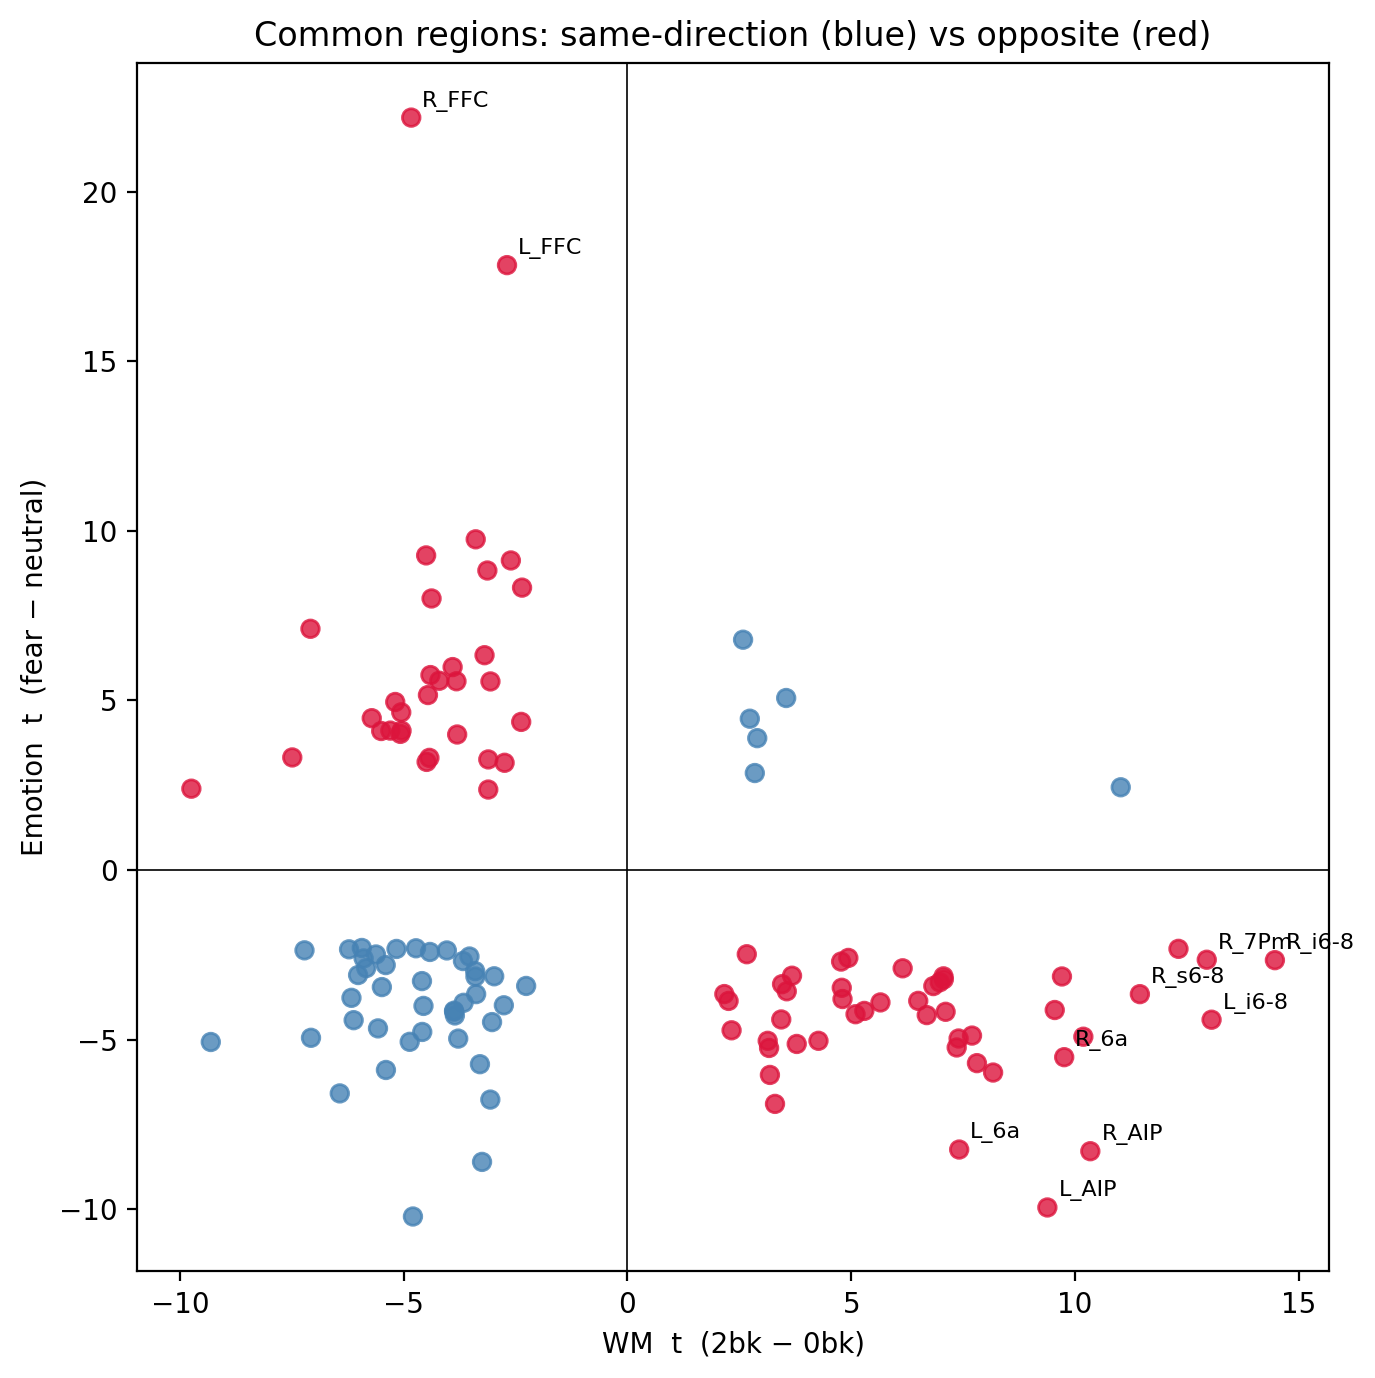

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

colors = common_regions['Direction of T-tests'].map({'same': 'steelblue', 'opposite': 'crimson'})
ax.scatter(common_regions['t_wm'], common_regions['t_emo'], c=colors, s=40, alpha=0.8)

ax.axhline(0, color='k', lw=0.6)
ax.axvline(0, color='k', lw=0.6)

# label the top few strongest regions
for _, r in common_regions.nlargest(10, 'strength').iterrows():
    ax.annotate(r['region'], (r['t_wm'], r['t_emo']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('WM  t  (2bk − 0bk)')
ax.set_ylabel('Emotion  t  (fear − neutral)')
ax.set_title('Common regions: same-direction (blue) vs opposite (red)')
plt.tight_layout(); plt.show()

In [ ]:
colors

0        crimson
1        crimson
2        crimson
3        crimson
4        crimson
5      steelblue
6        crimson
7        crimson
8        crimson
9        crimson
10       crimson
11       crimson
12       crimson
13     steelblue
14       crimson
15       crimson
16       crimson
17       crimson
18       crimson
19       crimson
20       crimson
21     steelblue
22       crimson
23       crimson
24     steelblue
25       crimson
26       crimson
27       crimson
28       crimson
29       crimson
30       crimson
31     steelblue
32     steelblue
33     steelblue
34       crimson
35     steelblue
36     steelblue
37     steelblue
38     steelblue
39     steelblue
40       crimson
41       crimson
42     steelblue
43     steelblue
44       crimson
45     steelblue
46     steelblue
47     steelblue
48       crimson
49       crimson
50       crimson
51     steelblue
52       crimson
53       crimson
54       crimson
55       crimson
56       crimson
57     steelblue
58       crims

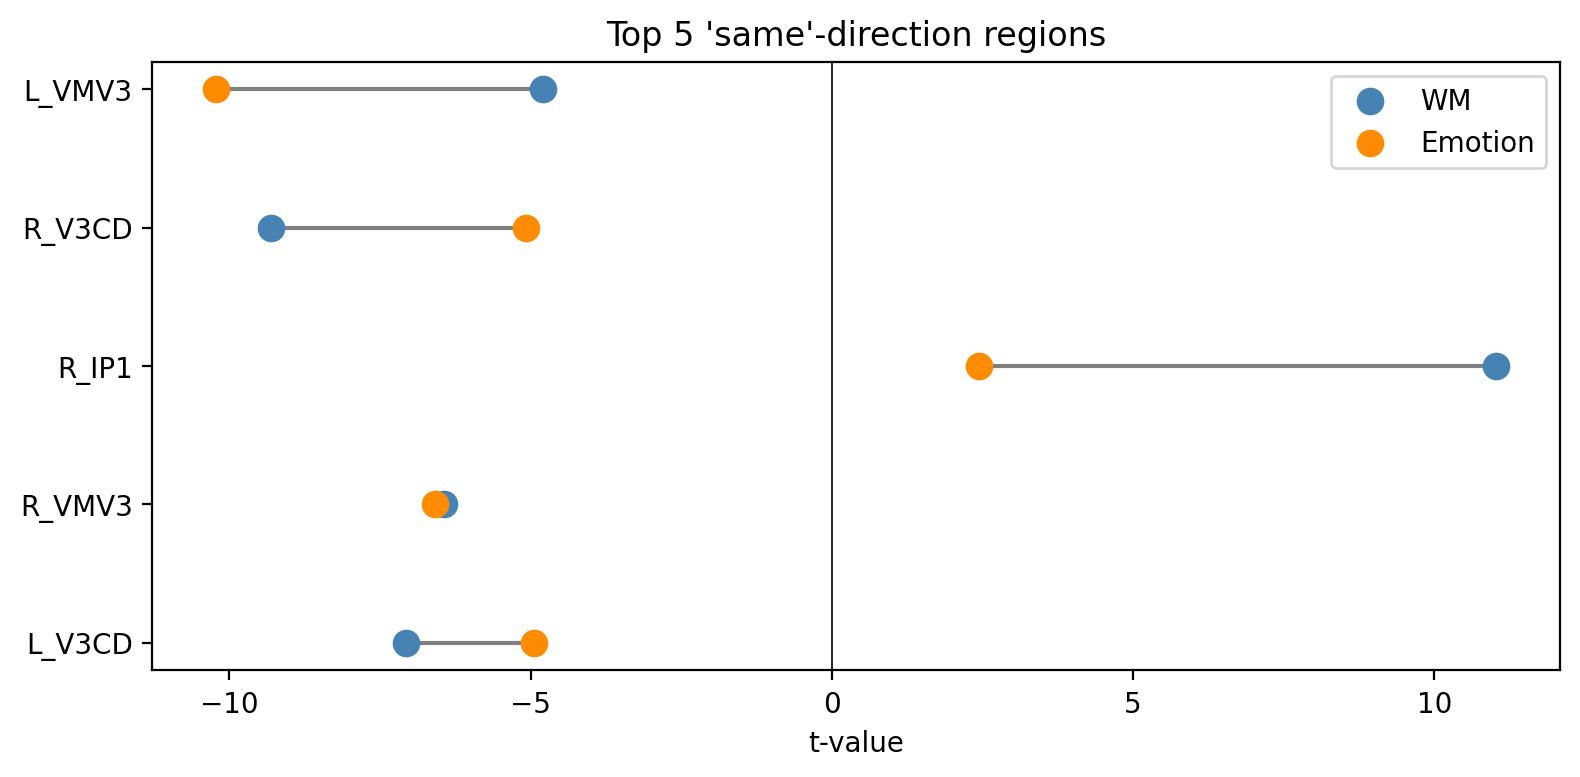

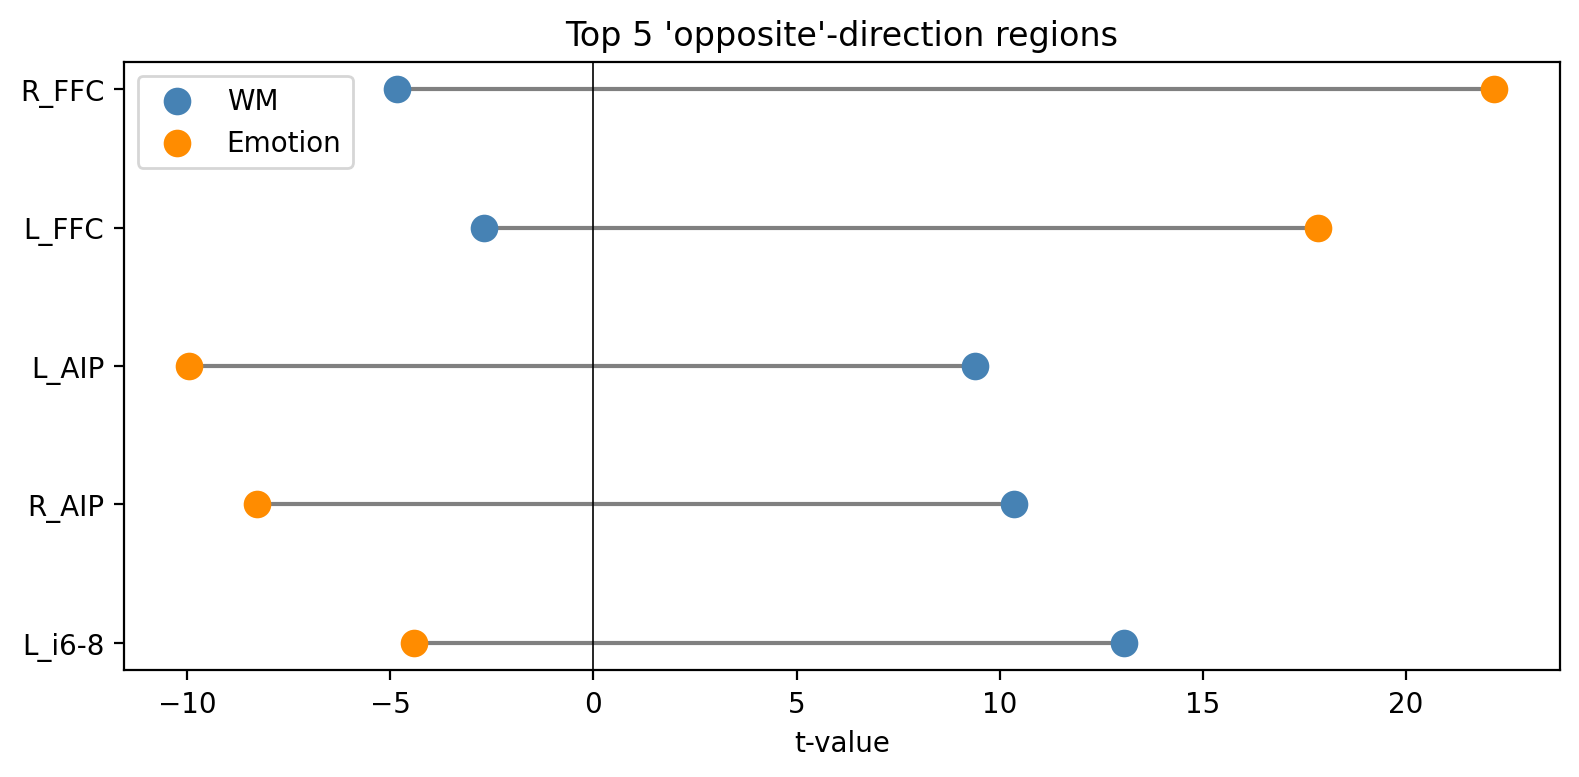

In [ ]:
def dumbbell(direction, n=5):
    d = (common_regions[common_regions['Direction of T-tests'] == direction]
         .sort_values('strength', ascending=False).head(n).iloc[::-1])
    y = range(len(d))
    plt.figure(figsize=(8, 0.6*len(d) + 1))
    plt.hlines(y, d['t_wm'], d['t_emo'], color='gray', lw=1.5, zorder=1)
    plt.scatter(d['t_wm'], y, color='steelblue', s=80, label='WM', zorder=2)
    plt.scatter(d['t_emo'], y, color='darkorange', s=80, label='Emotion', zorder=2)
    plt.axvline(0, color='k', lw=0.6)
    plt.yticks(y, d['region'])
    plt.xlabel('t-value'); plt.legend()
    plt.title(f"Top {n} '{direction}'-direction regions")
    plt.tight_layout(); plt.show()

dumbbell('same', 5)
dumbbell('opposite', 5)

In [ ]:
common_regions

,region,network_wm,mean_contrast_wm,t_wm,p_wm,p_fdr_wm,significant_wm,network_emo,mean_contrast_emo,t_emo,p_emo,p_fdr_emo,significant_emo,Direction of T-tests,strength
0,R_i6-8,Frontopariet,27.118630,14.470708,3.612173e-26,6.501911e-24,True,Frontopariet,-4.625779,-2.659932,9.117708e-03,2.001448e-02,True,opposite,17.130640
1,L_i6-8,Frontopariet,25.650871,13.055258,2.992925e-23,3.591510e-21,True,Frontopariet,-8.172035,-4.415392,2.575944e-05,1.117277e-04,True,opposite,17.470650
2,R_7Pm,Frontopariet,29.422133,12.947708,5.031302e-23,4.528172e-21,True,Frontopariet,-5.342097,-2.647224,9.443488e-03,2.060397e-02,True,opposite,15.594932
3,R_PFm,Frontopariet,16.154316,12.315552,1.090171e-21,7.849228e-20,True,Frontopariet,-3.028128,-2.326066,2.205443e-02,4.410886e-02,True,opposite,14.641618
4,R_s6-8,Frontopariet,23.704677,11.452725,7.672805e-20,3.452762e-18,True,Frontopariet,-7.687160,-3.661459,4.047074e-04,1.265689e-03,True,opposite,15.114184
5,R_IP1,Frontopariet,15.690898,11.025120,6.441511e-19,2.576604e-17,True,Frontopariet,4.705266,2.437872,1.655707e-02,3.465433e-02,True,same,13.462992
6,R_AIP,Language,14.299108,10.344950,1.936402e-17,6.337316e-16,True,Language,-12.852170,-8.292149,5.657364e-13,1.131473e-11,True,opposite,18.637098
7,R_46,Cingulo-Oper,18.655439,10.189044,4.234011e-17,1.270203e-15,True,Cingulo-Oper,-8.955382,-4.916825,3.495559e-06,1.823770e-05,True,opposite,15.105869
8,R_6a,Language,16.393706,9.761018,3.634236e-16,8.703909e-15,True,Language,-7.839327,-5.519692,2.730523e-07,1.965977e-06,True,opposite,15.280709
9,R_3a,Somatomotor,-10.737198,-9.748589,3.868404e-16,8.703909e-15,True,Somatomotor,3.080791,2.395651,1.847034e-02,3.821449e-02,True,opposite,12.144240


In [ ]:
# Экспорт в
#Thanks Anna

common_regions.to_excel('significant_regions_t_tests.xlsx', index=True)

In [ ]:

contrast.shape

(100, 360)

In [ ]:
## Further Analysis
## finding correlation between the t-test results for Working Memory and Emotion Contrasts

from scipy import stats

def full_tmap(contrast):
    t, _ = stats.ttest_1samp(contrast, popmean=0, axis=0)
    return t          # length 360, original region order

t_wm  = full_tmap(contrast)       # WM: 2bk - 0bk
t_emo = full_tmap(emo_contrast)   # Emotion: faces - shapes


In [ ]:
len(t_wm)

360

In [ ]:
from scipy.stats import pearsonr, spearmanr

r, p   = pearsonr(t_wm, t_emo)
rho, _ = spearmanr(t_wm, t_emo)

print(f"Pearson  r = {r:.3f}  (p = {p:.1e})")
print(f"Spearman ρ = {rho:.3f}")

## Claude suggested two different methods to find the correlation coefficients
## Pearson works on the raw tvalues itself and Spearman method works on the
## ranks of the t values

Pearson  r = -0.213  (p = 4.5e-05)
Spearman ρ = -0.213


## The Following is the Main result

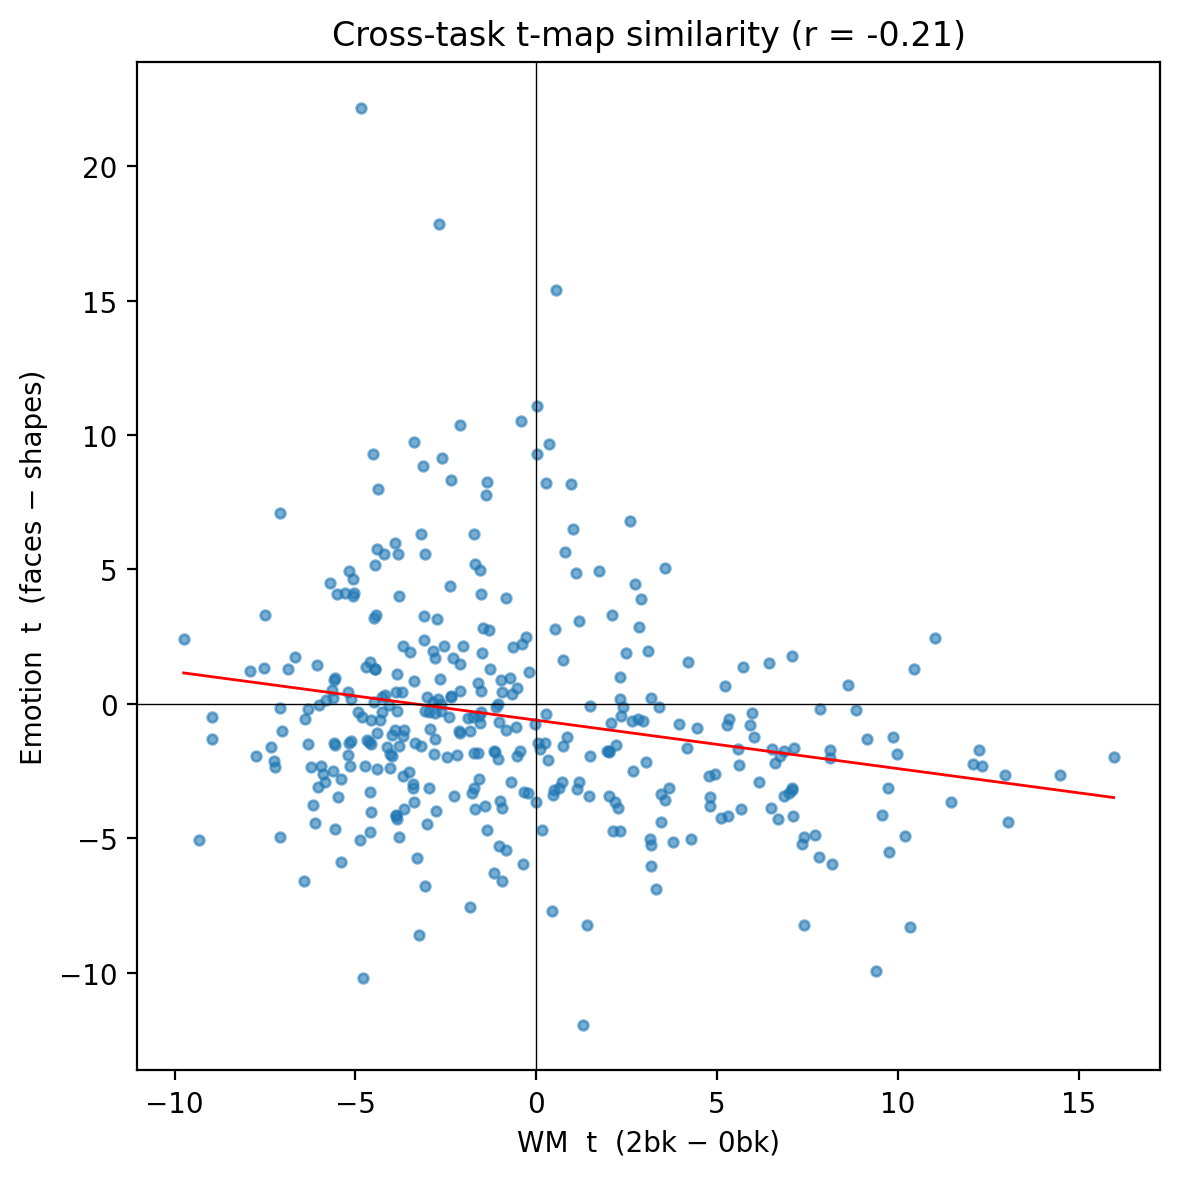

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))
plt.scatter(t_wm, t_emo, s=12, alpha=0.6)

# regression line
b, a = np.polyfit(t_wm, t_emo, 1)
xs = np.array([t_wm.min(), t_wm.max()])
plt.plot(xs, a + b*xs, 'r-', lw=1)

plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.xlabel('WM  t  (2bk − 0bk)')
plt.ylabel('Emotion  t  (faces − shapes)')
plt.title(f'Cross-task t-map similarity (r = {r:.2f})')
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
networks = np.array(region_info['network'])
for net in np.unique(networks):
    m = networks == net
    if m.sum() >= 5:
        r_net, _ = pearsonr(t_wm[m], t_emo[m])
        print(f"{net:20s} n={m.sum():3d}  r={r_net:+.2f}")

Auditory             n= 15  r=-0.11
Cingulo-Oper         n= 56  r=-0.26
Default              n= 23  r=-0.20
Dorsal-atten         n=  7  r=-0.36
Frontopariet         n= 50  r=-0.42
Language             n= 23  r=-0.54
Orbito-Affec         n=  6  r=-0.66
Posterior-Mu         n= 77  r=-0.25
Somatomotor          n= 39  r=-0.69
Visual1              n=  6  r=+0.10
Visual2              n= 54  r=+0.18


In [ ]:
print(common_regions['Direction of T-tests'].value_counts())

Direction of T-tests
opposite    78
same        48
Name: count, dtype: int64


In [ ]:
print("SAME direction:")
print(common_regions[common_regions['Direction of T-tests']=='same']['network_wm'].value_counts())
print("\nOPPOSITE direction:")
print(common_regions[common_regions['Direction of T-tests']=='opposite']['network_wm'].value_counts())

SAME direction:
network_wm
Visual2         14
Cingulo-Oper    12
Somatomotor      9
Posterior-Mu     6
Frontopariet     2
Auditory         2
Language         1
Default          1
Dorsal-atten     1
Name: count, dtype: int64

OPPOSITE direction:
network_wm
Cingulo-Oper    19
Visual2         16
Frontopariet    12
Language        10
Posterior-Mu    10
Default          4
Somatomotor      2
Auditory         2
Ventral-Mult     2
Visual1          1
Name: count, dtype: int64


In [ ]:
network_df = pd.DataFrame({
    "Regions": regions[0],
    "Network": regions[1],
    "Misc": regions[2]  # Make sure to use index 2 instead of 3, as it is 0-indexed
})

# Display the first few rows to verify
network_df.head()

,Regions,Network,Misc
0,R_V1,Visual1,2.209
1,R_MST,Visual2,2.05561
2,R_V6,Visual2,2.1498
3,R_V2,Visual2,2.15347
4,R_V3,Visual2,2.07251


In [ ]:
network_df[network_df['Network']=='Dorsal-atten']

,Regions,Network,Misc
26,R_PCV,Dorsal-atten,1.85286
139,R_TPOJ2,Dorsal-atten,1.89296
140,R_TPOJ3,Dorsal-atten,1.89379
206,L_PCV,Dorsal-atten,1.78718
207,L_STV,Dorsal-atten,1.7754
319,L_TPOJ2,Dorsal-atten,1.79203
320,L_TPOJ3,Dorsal-atten,1.77318


In [ ]:
common_regions

,region,network_wm,mean_contrast_wm,t_wm,p_wm,p_fdr_wm,significant_wm,network_emo,mean_contrast_emo,t_emo,p_emo,p_fdr_emo,significant_emo,Direction of T-tests,strength
0,R_i6-8,Frontopariet,27.118630,14.470708,3.612173e-26,6.501911e-24,True,Frontopariet,-4.625779,-2.659932,9.117708e-03,2.001448e-02,True,opposite,17.130640
1,L_i6-8,Frontopariet,25.650871,13.055258,2.992925e-23,3.591510e-21,True,Frontopariet,-8.172035,-4.415392,2.575944e-05,1.117277e-04,True,opposite,17.470650
2,R_7Pm,Frontopariet,29.422133,12.947708,5.031302e-23,4.528172e-21,True,Frontopariet,-5.342097,-2.647224,9.443488e-03,2.060397e-02,True,opposite,15.594932
3,R_PFm,Frontopariet,16.154316,12.315552,1.090171e-21,7.849228e-20,True,Frontopariet,-3.028128,-2.326066,2.205443e-02,4.410886e-02,True,opposite,14.641618
4,R_s6-8,Frontopariet,23.704677,11.452725,7.672805e-20,3.452762e-18,True,Frontopariet,-7.687160,-3.661459,4.047074e-04,1.265689e-03,True,opposite,15.114184
5,R_IP1,Frontopariet,15.690898,11.025120,6.441511e-19,2.576604e-17,True,Frontopariet,4.705266,2.437872,1.655707e-02,3.465433e-02,True,same,13.462992
6,R_AIP,Language,14.299108,10.344950,1.936402e-17,6.337316e-16,True,Language,-12.852170,-8.292149,5.657364e-13,1.131473e-11,True,opposite,18.637098
7,R_46,Cingulo-Oper,18.655439,10.189044,4.234011e-17,1.270203e-15,True,Cingulo-Oper,-8.955382,-4.916825,3.495559e-06,1.823770e-05,True,opposite,15.105869
8,R_6a,Language,16.393706,9.761018,3.634236e-16,8.703909e-15,True,Language,-7.839327,-5.519692,2.730523e-07,1.965977e-06,True,opposite,15.280709
9,R_3a,Somatomotor,-10.737198,-9.748589,3.868404e-16,8.703909e-15,True,Somatomotor,3.080791,2.395651,1.847034e-02,3.821449e-02,True,opposite,12.144240


In [ ]:
emo_sig_regions

,region,network,mean_contrast,t,p,p_fdr,significant
0,R_FFC,Visual2,53.977516,22.181152,3.405732e-40,1.226063e-37,True
1,L_FFC,Visual2,46.161711,17.831839,1.119640e-32,2.015353e-30,True
2,R_PIT,Visual2,43.443582,15.378688,5.483731e-28,6.580477e-26,True
3,L_PFt,Language,-14.746156,-11.934013,7.100573e-21,6.390516e-19,True
4,L_PIT,Visual2,39.278350,11.072732,5.080066e-19,3.657648e-17,True
5,L_V1,Visual1,21.118244,10.537370,7.380253e-18,4.428152e-16,True
6,R_V3,Visual2,21.275663,10.388831,1.553875e-17,7.991358e-16,True
7,L_VMV3,Visual2,-22.852374,-10.217205,3.675907e-17,1.654158e-15,True
8,L_AIP,Language,-16.366394,-9.951247,1.397528e-16,5.590110e-15,True
9,R_V1,Visual1,20.357421,9.748175,3.876469e-16,1.395529e-14,True


In [ ]:
#  NMA provides an atlas. Run this cell to download it
import os, requests

# NMA provides an atlas
fname = f"{HCP_DIR}/atlas.npz"
url = "https://osf.io/j5kuc/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

with np.load(fname) as dobj:
  atlas = dict(**dobj)

In [ ]:
print(atlas.keys())
for k in atlas:
    print(k, np.shape(atlas[k]))

dict_keys(['labels_R', 'labels_L', 'coords'])
labels_R (10242,)
labels_L (10242,)
coords (360, 3)


In [ ]:
print("R labels:", atlas['labels_R'].min(), atlas['labels_R'].max())
print("L labels:", atlas['labels_L'].min(), atlas['labels_L'].max())
print("unique R:", len(np.unique(atlas['labels_R'])))

R labels: -1 179
L labels: -1 359
unique R: 181


In [ ]:

print(emo_contrast.shape)
def full_stats(contrast):
  t,p = stats.ttest_1samp(contrast,popmean=0, axis=0)
  reject, p_fdr, _,_ = multipletests(p, alpha=0.05, method='fdr_bh')
  return t,p_fdr

(100, 360)


In [ ]:
##Plotting Brain map

## Thanks Anna

from nilearn import plotting, datasets
#CLAUDE


fsaverage = datasets.fetch_surf_fsaverage()
THRESHOLD = 0.05

t_em,p_em= full_stats(emo_contrast)
# t_em = emo_sig_regions['t'].values
# p_em = emo_sig_regions['p_fdr'].values

# Replace non‑significant regions with NaN
t_em_sig = np.where(p_em < THRESHOLD, t_em, np.nan)

def project(labels, values):
    surf = np.full(labels.shape, np.nan)         # medial wall stays NaN
    mask = labels >= 0                           # -1 = medial wall, exclude it
    surf[mask] = values[labels[mask]]            # direct index, no offset
    return surf

surf_em_right = project(atlas['labels_R'], t_em_sig)
surf_em_left  = project(atlas['labels_L'], t_em_sig)


vals = surf_em_right[~np.isnan(surf_em_right)]
vmax = np.abs(vals).max() if len(vals) else 1.0

plotting.view_surf(
    fsaverage['infl_right'], surf_em_right,
    symmetric_cmap=True, cmap='RdBu_r', colorbar=True,
    vmax=vmax, vmin=-vmax,
    title="Emotion: fear − neutral (FDR<0.05), right"
)

# # Map to right hemisphere vertices
# surf_em_right = t_em_sig[atlas['labels_R']]

# # Compute symmetric vmax manually
# vals = surf_em_right[~np.isnan(surf_em_right)]
# vmax_em = max(abs(vals.max()), abs(vals.min())) if len(vals) > 0 else 1.0

# # Plot
# view_em_r = plotting.view_surf(
#     fsaverage['infl_right'], surf_em_right,
#     symmetric_cmap=True, cmap='RdBu_r',
#     title="Emotion: fear > neutral (FDR<0.05) right",
#     colorbar=True, vmax=vmax_em, vmin=-vmax_em
# )
# view_em_r